# Basic NLP with text records

A simple handoff from `crategraph` to NLP tools.

We do not read files directly. The RO-Crate graph picks which files to look at, and `text_records()` hands their text — with provenance and entity metadata — to TextBlob for per-document features and `wordcloud` for an aggregate view.

## Running this notebook

While `crategraph` is still pre-release, launch Jupyter from the repository root with `uv run`, pulling in the project (with all extras) plus the notebook-specific NLP dependencies:

```bash
uv run --all-extras --with jupyter,textblob,wordcloud,matplotlib jupyter notebook
```

Once the package is published, a plain `pip install crategraph textblob wordcloud matplotlib` in your environment will be enough.

In [ ]:
from collections import Counter

import pandas as pd
from textblob import TextBlob

from crategraph import Crate

## Load the crate

Load the Australian Corpus of English crate from `data/`.

In [ ]:
crate = Crate("data/ldaca/Australian_Corpus_of_English")
crate.summary()

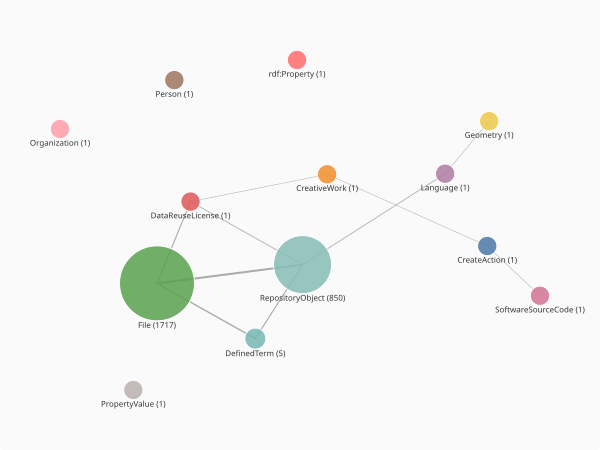

In [3]:
crate.glimpse()

## Annotate files with graph-derived genre

Use `annotate_entities()` to derive three properties: the related `genre` name, a `has_genre` boolean, and an `is_plain_text` boolean based on the file name. Chain `.where(has_genre=True, is_plain_text=True)` straight after so `tagged` contains only the clean text files we want to analyse.


In [4]:
tagged = crate.annotate_entities(
    genre=lambda entity: entity.related("ldac:linguisticGenre").join("name"),
    has_genre=lambda entity: entity.has("ldac:linguisticGenre"),
    is_plain_text=lambda entity: entity.type == "File" and entity.id.endswith("-plain.txt"),
)

# Keep the clean text files that have a genre associated.
tagged = tagged.where(has_genre=True, is_plain_text=True)

In [5]:
tagged

Graph(426 entities, 0 relationships, source='../../data/ldaca/Australian_Corpus_of_English')

## Inspect what we have

Two peeks before slicing the corpus: an annotated **entity** to confirm the `genre` property landed on a file alongside its native properties, then a **text record** to see the row shape that downstream NLP will consume. `text_records()` defaults to file-sourced text, so no entity-type filter is needed first.

In [6]:
tagged.entity_records()[0]

{'id': 'A43b-plain.txt',
 'label': 'A43b#Text',
 'type': 'File',
 'types': ['File'],
 'contentSize': '1571',
 'description': 'TXT derivative of the original work, without markup',
 'encodingFormat': ['text/plain',
  'https://www.nationalarchives.gov.uk/PRONOM/x-fmt/111'],
 'extent': 1571,
 'genre': 'Report',
 'has_genre': True,
 'is_plain_text': True,
 'ldac:communicationMode': 'https://w3id.org/ldac/terms#WrittenLanguage',
 'ldac:linguisticGenre': 'https://w3id.org/ldac/terms#Report',
 'license': 'https://creativecommons.org/licenses/by/4.0/',
 'name': 'A43b#Text',
 'size': 1571}

In [7]:
sample_record = next(tagged.text_records(include_properties=["name", "genre"]))

{**sample_record, "text": sample_record["text"][:500] + "..."}

{'source_id': 'Australian_Corpus_of_English',
 'entity_id': 'A43b-plain.txt',
 'source_kind': 'file',
 'entity_types': ('File',),
 'text': 'Help is at hand\n\nA NUMBER of government services are available to help elderly people who\nneed extra care, but who wish to retain independence in their own homes.\n  Home nursing assistance is available to people who are chronically ill\nor convalescing after hospitalisation.\n  These services are run by several different organisations.\n  Some are run by the local council, others by community health centres and\nsome by church groups.\n  For advice about these services, you could ask your doctor or y...',
 'name': 'A43b#Text',
 'genre': 'Report'}

Count the derived genre annotations to see what is available, then pick two genres to compare. The ACE crate has both `-raw.txt` files with XML markup and cleaner `-plain.txt` files, so we use the file names to keep the plain text derivatives for analysis.

In [8]:
genre_counts = Counter()
for record in tagged.entity_records():
    genre_counts[record["genre"]] += 1

genre_counts

Counter({'Report': 292, 'Informational': 91, 'Narrative': 34, 'Ludic': 9})

## Walk one genre end-to-end

Pick `Report` and follow the chain: filter to the Report subgraph, extract text records with provenance kept, then add per-document features.

In [9]:
report_graph = tagged.where(genre="Report")
report_records = list(report_graph.text_records(include_properties=["name", "genre"]))

pd.DataFrame(report_records[:10])[["entity_id", "genre", "name", "text"]]

,entity_id,genre,name,text
0,B03c-plain.txt,Report,B03c#Text,U.S.POLL BLOW TO AUSTRALIA\n\nTHE success of t...
1,A40c-plain.txt,Report,A40c#Text,Here's how the drivers shape up for the grand ...
2,A43b-plain.txt,Report,A43b#Text,Help is at hand\n\nA NUMBER of government serv...
3,B10p-plain.txt,Report,B10p#Text,Water rate a ripoff\n\nMY wife and I were meas...
4,A28k-plain.txt,Report,A28k#Text,Piggott pays to prevent charges LONDON:\n\n F...
5,B02b-plain.txt,Report,B02b#Text,Verdict of world's financial markets will be c...
6,A25j-plain.txt,Report,A25j#Text,Warning on PIN code safeguards By Deirdre Will...
7,B05e-plain.txt,Report,B05e#Text,THE SUN SAYS ...\nCLEAN OUT THE RORTS\n\nTHE S...
8,A14-plain.txt,Report,A14#Text,A Housewife's Lot ...is not an easy one. In p...
9,G49a-plain.txt,Report,G49a#Text,Aboriginality in the art of Byram Mansell by M...


In [10]:
def analyse_record(record):
    blob = TextBlob(record["text"])
    return {
        **record,
        "word_count": len(blob.words),
        "polarity": blob.sentiment.polarity,
    }


report_analysed = [analyse_record(record) for record in report_records]
pd.DataFrame(report_analysed[:10])[["entity_id", "genre", "word_count", "polarity", "name"]]

,entity_id,genre,word_count,polarity,name
0,B03c-plain.txt,Report,355,0.112801,B03c#Text
1,A40c-plain.txt,Report,189,0.133722,A40c#Text
2,A43b-plain.txt,Report,251,0.062000,A43b#Text
3,B10p-plain.txt,Report,120,0.006204,B10p#Text
4,A28k-plain.txt,Report,86,0.114286,A28k#Text
5,B02b-plain.txt,Report,573,0.065443,B02b#Text
6,A25j-plain.txt,Report,365,0.014474,A25j#Text
7,B05e-plain.txt,Report,194,0.066458,B05e#Text
8,A14-plain.txt,Report,2052,0.159182,A14#Text
9,G49a-plain.txt,Report,1705,0.156372,G49a#Text


## Repeat for another genre

Same pipeline for `Narrative`, compressed now that each step is familiar.

In [11]:
narrative_graph = tagged.where(genre="Narrative")
narrative_records = list(narrative_graph.text_records(include_properties=["name", "genre"]))
narrative_analysed = [analyse_record(record) for record in narrative_records]
pd.DataFrame(narrative_analysed[:10])[["entity_id", "genre", "word_count", "polarity", "name"]]

,entity_id,genre,word_count,polarity,name
0,L05-plain.txt,Narrative,2073,0.103077,L05#Text
1,P14-plain.txt,Narrative,2041,0.098810,P14#Text
2,W15-plain.txt,Narrative,2032,-0.002010,W15#Text
3,L08-plain.txt,Narrative,2060,0.098876,L08#Text
4,K25-plain.txt,Narrative,2031,0.057747,K25#Text
5,K23-plain.txt,Narrative,2068,0.040440,K23#Text
6,S16-plain.txt,Narrative,2022,0.064658,S16#Text
7,P08-plain.txt,Narrative,2070,0.099240,P08#Text
8,N03-plain.txt,Narrative,2018,0.027911,N03#Text
9,L01-plain.txt,Narrative,2069,0.143344,L01#Text


## Compare per-document features

The `genre` column came from RO-Crate relationships, not from file names — but once the records carry it, pandas can group on it like any other column.

In [12]:
(
    pd.DataFrame(report_analysed + narrative_analysed)
    .groupby("genre")
    .agg(
        documents=("entity_id", "count"),
        mean_words=("word_count", "mean"),
        mean_polarity=("polarity", "mean"),
    )
)

,documents,mean_words,mean_polarity
genre,,,
Narrative,34,1927.029412,0.071583
Report,292,649.756849,0.087211


## Aggregate view: word clouds per genre

Per-document features summarise each file. To see what each genre talks *about*, concatenate all the text in a subgraph and let `wordcloud` count words across the whole genre, with stopwords removed. We start with the default English stopword list and add a few high-frequency fillers that otherwise dominate this corpus.


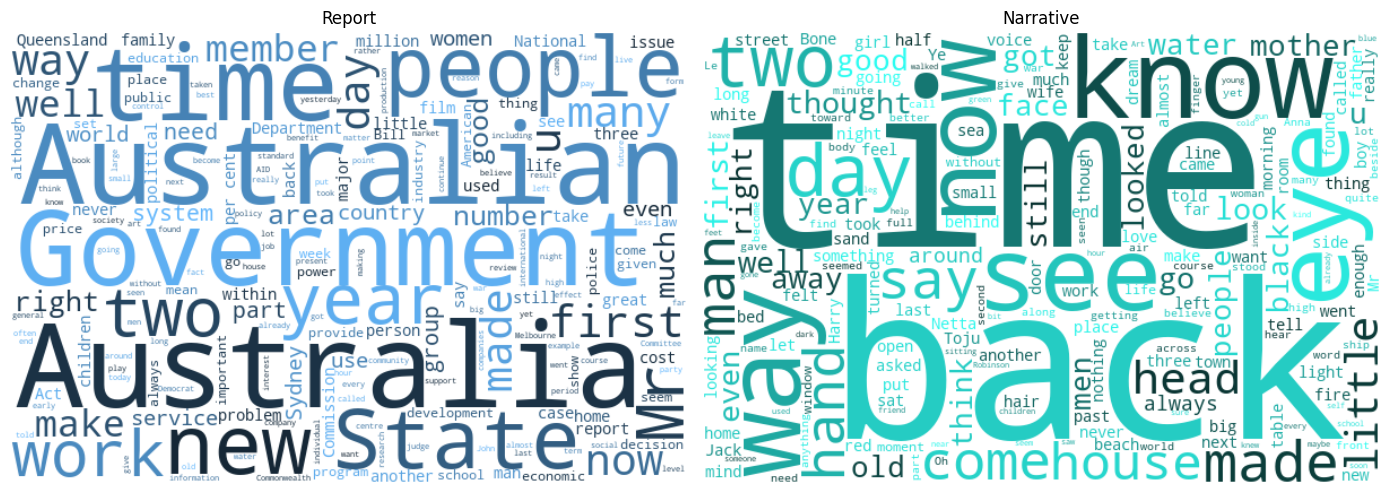

In [13]:
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS, WordCloud, get_single_color_func

stopwords = STOPWORDS | {
    "one",
    "said",
    "will",
    "would",
    "could",
    "may",
    "might",
    "must",
}


def render_cloud(ax, genre, records, colour):
    text = " ".join(record["text"] for record in records)
    cloud = WordCloud(
        stopwords=stopwords,
        background_color="white",
        color_func=get_single_color_func(colour),
        width=600,
        height=400,
    ).generate(text)
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(genre)
    ax.axis("off")


fig, (report_ax, narrative_ax) = plt.subplots(1, 2, figsize=(14, 6))
render_cloud(report_ax, "Report", report_records, colour="steelblue")
render_cloud(narrative_ax, "Narrative", narrative_records, colour="lightseagreen")
plt.tight_layout()
plt.show()